In [1]:
#pip install seaborn
#!pip install scikit-learn


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,MaxAbsScaler,Normalizer,FunctionTransformer
from pandas.api.types import is_numeric_dtype
import warnings
warnings.filterwarnings('ignore')

In [3]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [4]:
df= sns.load_dataset('iris')

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [7]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [10]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [11]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [12]:
df.duplicated().sum()

np.int64(1)

In [13]:
dup=df[df.duplicated(keep=False)]

In [14]:
dup

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


In [15]:
df= df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Encoding


In [18]:
le= LabelEncoder()

In [19]:
df1=df.copy()
df2=df.copy()

In [20]:
df1['species']= le.fit_transform(df1['species'])

In [21]:
df1.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


!Shit loading

In [22]:
X = df1[["sepal_length", "sepal_width"]]
y = df1["species"]

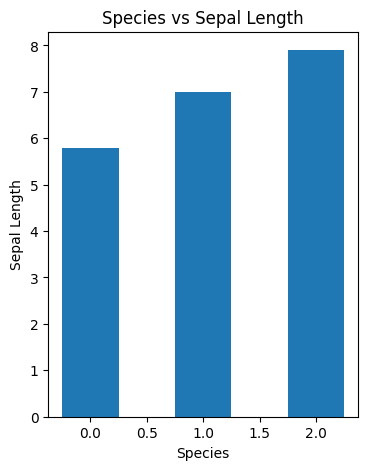

In [23]:
plt.figure(figsize=(4,5))
plt.bar(df1['species'],df1['sepal_length'], width=0.5, linewidth=2)
plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.title('Species vs Sepal Length')
plt.show()

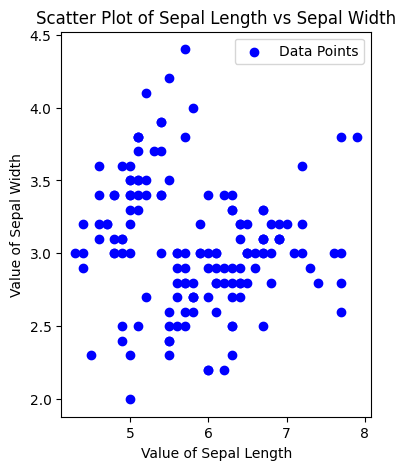

In [24]:
plt.figure(figsize=(4,5))
plt.xlabel('Value of Sepal Length')
plt.ylabel('Value of Sepal Width')
plt.title('Scatter Plot of Sepal Length vs Sepal Width')
plt.scatter(X['sepal_length'], X['sepal_width'], c='blue', label='Data Points')
plt.legend()
plt.show()

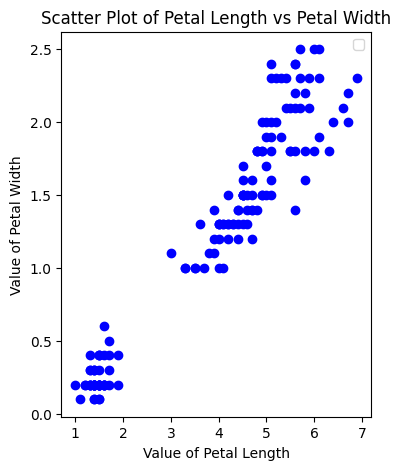

In [26]:
plt.figure(figsize=(4,5))
plt.xlabel('Value of Petal Length')
plt.ylabel('Value of Petal Width')
plt.title('Scatter Plot of Petal Length vs Petal Width')
plt.scatter(df1['petal_length'], df1['petal_width'], c='blue')
plt.legend()
plt.show()

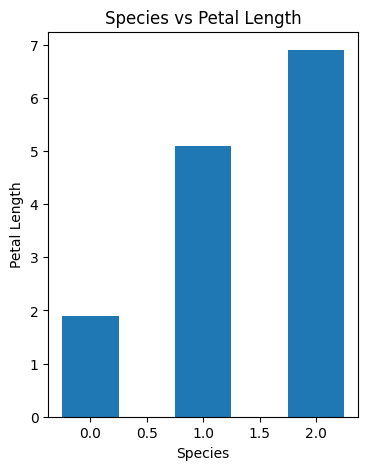

In [27]:
plt.figure(figsize=(4,5))
plt.bar(df1['species'],df1['petal_length'], width=0.5, linewidth=2)
plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.title('Species vs Petal Length')
plt.show()

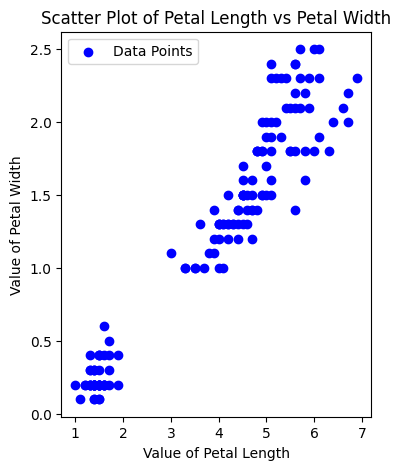

In [31]:
plt.figure(figsize=(4,5))
plt.xlabel('Value of Petal Length')
plt.ylabel('Value of Petal Width')
plt.title('Scatter Plot of Petal Length vs Petal Width')
plt.scatter(df1['petal_length'], df1['petal_width'], c='blue', label='Data Points')
plt.legend()
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'bordercolor'

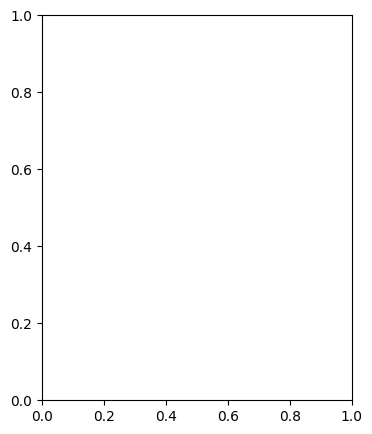

In [34]:
plt.figure(figsize=(4,5))
plt.bar(df1['sepal_length'],df1['sepal_width'], width=0.5, linewidth=2, bordercolor="black")
plt.xlabel('Species')
plt.ylabel('Sepal Length')
plt.title('Species vs Sepal Length')
plt.show()

AttributeError: Rectangle.set() got an unexpected keyword argument 'bordercolor'

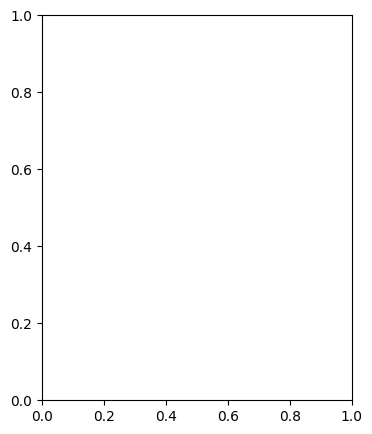

In [35]:
plt.figure(figsize=(4,5))
plt.bar(df1['petal_length'],df1['petal_width'], width=0.5, linewidth=2, bordercolor="black")
plt.xlabel('Species')
plt.ylabel('Petal Length')
plt.title('Species vs Petal Length')
plt.show()

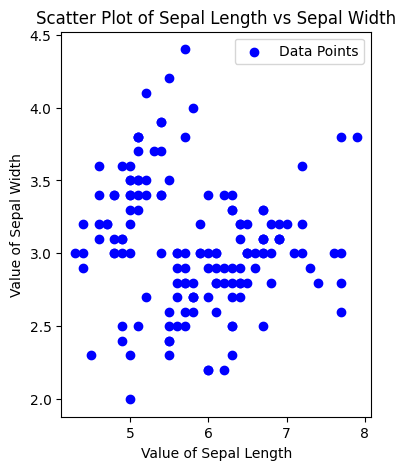

In [36]:
plt.figure(figsize=(4,5))
plt.xlabel('Value of Sepal Length')
plt.ylabel('Value of Sepal Width')
plt.title('Scatter Plot of Sepal Length vs Sepal Width')
plt.scatter(df1['sepal_length'], df1['sepal_width'], c='blue', label='Data Points')
plt.legend()
plt.show()